# Aplicações de análise de frequência

## Registro de imagens de drone

É possível criar uma única imagem global a partir de pequenas fotografias obtidas durante o voo de um drone. O código abaixo mostra um exemplo para duas imagens.


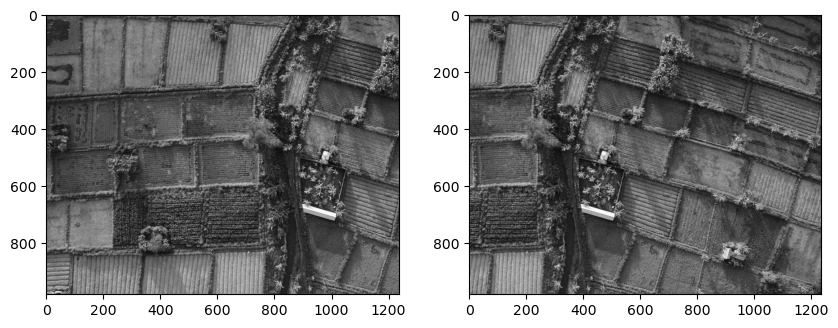

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.fft import fft2, ifft2, fftshift

img1 = np.array(Image.open("../../dados/mosaic1.jpg"))
img2 = np.array(Image.open("../../dados/mosaic2.jpg"))

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(img1, cmap="gray")
axs[1].imshow(img2, cmap="gray")

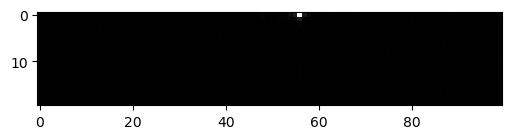

In [8]:
def normalized_cross_correlation(img1, img2):
    """
    Calcula a correlação-cruzada entre duas imagens no domínio da frequência.
    """

    # Transformada de Fourier das duas imagens
    Fimg1 = fft2(img1)
    Fimg2 = fft2(img2)
    
    # Para calcularmos a correlação-cruzada ao invés da convolução, precisamos calcular a
    # conjugada da segunda imagem no domínio da frequência
    numerator = Fimg1 * np.conj(Fimg2)
    
    # Denominador: Magnitude do produto (para normalização)
    denominator = np.abs(numerator)
    
    # Espectro de potência cruzada normalizado
    cps = numerator / (denominator + 1e-12) # 1e-12 para evitar div zero

    # Volta para o domínio espacial via IFFT
    # O resultado deve ser um impulso (pico de Dirac) na posição do deslocamento
    correlation = np.abs(ifft2(cps))

    return correlation

correlation = normalized_cross_correlation(img1, img2)
plt.figure(figsize=(6, 6))
plt.imshow(correlation[:20, 450:550], cmap="gray")

In [9]:
def find_maximum(correlation):
    """
    Encontra o pico de correlação que indica o deslocamento (dy, dx).
    """
    
    # Encontra o índice do valor máximo (pico)
    dy, dx = np.unravel_index(np.argmax(correlation), correlation.shape)
    
    # Ajuste para deslocamentos negativos (Wrap-around da FFT)
    # Se o pico está na segunda metade da matriz, o deslocamento é negativo
    h, w = correlation.shape
    if dy > h // 2:
        dy -= h
    if dx > w // 2:
        dx -= w
    
    return int(dy), int(dx)

dy, dx = find_maximum(correlation)
print(f"Deslocamento estimado: (dy, dx) = ({dy}, {dx})")

Deslocamento estimado: (dy, dx) = (0, 506)


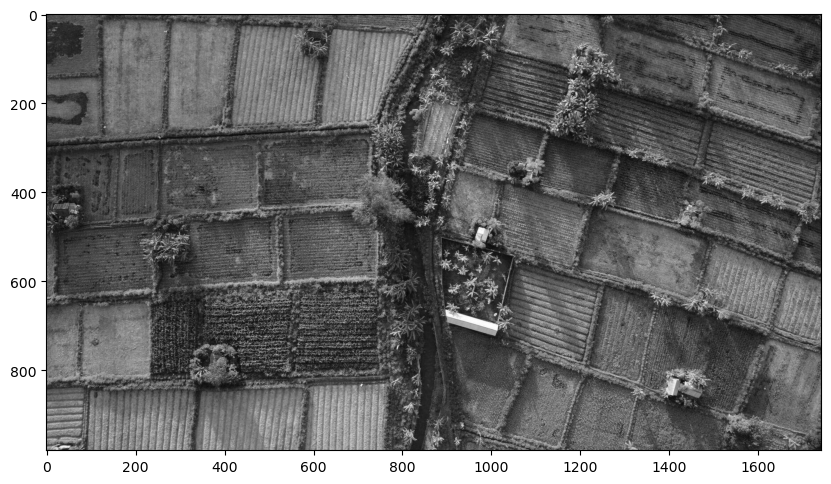

In [10]:
def build_mosaic(img1, img2, dx, dy):
    """
    Calcula o deslocamento e constrói uma imagem que une as duas.
    Assume que img2 está deslocada em relação a img1.
    """

    # Determinar o tamanho da tela final (canvas) para conter as duas imagens
    h, w = img1.shape
    min_y, max_y = min(0, dy), max(h, h + dy)
    min_x, max_x = min(0, dx), max(w, w + dx)
    
    canvas_h = max_y - min_y
    canvas_w = max_x - min_x
    
    # Criar canvas vazio
    mosaic = np.zeros((canvas_h, canvas_w), dtype=img1.dtype)
    
    # Posicionar imagens (ajustando pelo offset mínimo para evitar índices negativos)
    offset_y, offset_x = -min_y, -min_x
    
    # Imagem 1 na posição (0,0) relativa ao offset
    mosaic[offset_y : offset_y + h, offset_x : offset_x + w] = img1
    
    # Imagem 2 na posição (dy, dx) relativa ao offset
    # Usamos o máximo para lidar com sobreposição simples
    img2_y, img2_x = offset_y + dy, offset_x + dx
    mosaic[img2_y : img2_y + h, img2_x : img2_x + w] = np.maximum(
        mosaic[img2_y : img2_y + h, img2_x : img2_x + w], img2
    )
    
    return mosaic

mosaic_result = build_mosaic(img1, img2, dx, dy)

plt.figure(figsize=(10, 6))
plt.imshow(mosaic_result, "gray")

## Marca d'água em imagens

Vamos ler uma imagem que possui uma marca d'água no espectro, que é invisível a olho nu.

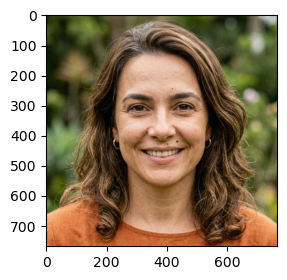

In [11]:
import numpy as np
from scipy.fft import fft2, fftshift
import matplotlib.pyplot as plt
from PIL import Image

img = np.array(Image.open("../../dados/foto_artificial.png"))
plt.imshow(img)

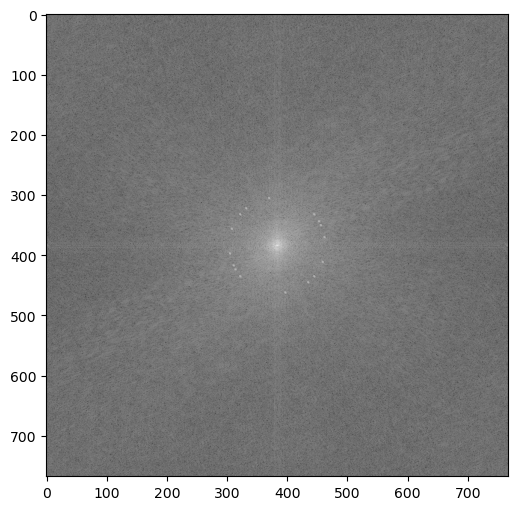

In [13]:
blue = img[:, :, 2]

# Calcula o espectro
fft_blue = fftshift(fft2(blue))
magnitude = np.abs(fft_blue)

plt.figure(figsize=(6, 6))
plt.imshow(np.log(magnitude), cmap="gray")

A imagem possui pequenos picos de frequência em um raio específico do espectro. Esses picos podem ser usados para representar, por exemplo, um número binário contendo um código.

Text(0, 0.5, 'Intensidade')

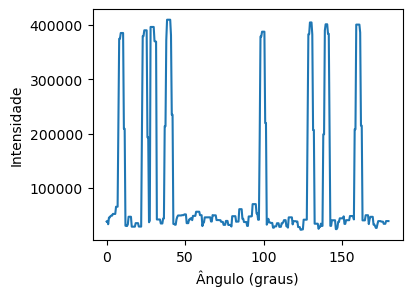

In [13]:
def extract_watermark(img, radius, n=360, window_size=3):
    """
    Extrai as amplitudes do espectro ao longo de um círculo de raio R.
    
    Parâmetros:
    - img: Array 2D contendo a imagem com a marca d'água.
    - radius: O raio R onde a marca foi escondida.
    - n: Resolução angular (360 = 1 amostra por grau).
    - window_size: Tamanho da janela de busca para tolerar arredondamentos de pixel.
    
    Retorna:
    - angulos: Array com os ângulos avaliados.
    - assinatura: Array 1D com a intensidade máxima encontrada em cada ângulo.
    """
    # Calcula a magnitude do espectro
    F = fftshift(fft2(img))
    mag = np.abs(F)
    
    h, w = mag.shape
    cy, cx = h // 2, w // 2
    offset = window_size // 2
    
    angles = np.linspace(0, 180, n, endpoint=False)
    watermark = np.zeros(n)
    
    # Varredura Circular
    for i, angle in enumerate(angles):
        theta = np.deg2rad(angle)
        
        # Calcula a coordenada x e y
        x = int(cx + radius * np.cos(theta))
        y = int(cy - radius * np.sin(theta))
        
        # Garante que não vamos acessar fora da matriz
        if (offset <= x < w - offset) and (offset <= y < h - offset):
            region = mag[y-offset : y+offset+1, x-offset : x+offset+1]
            watermark[i] = np.max(region)
            
    return angles, watermark

# Raio no qual a marca d'água foi escondida
radius = 80

angles, watermark = extract_watermark(blue, radius)

plt.plot(angles, watermark)
plt.xlabel('Ângulo (graus)')
plt.ylabel('Intensidade')

## Compressão de imagens

O formato jpeg utiliza a DFT para comprimir imagens. Veremos um exemplo simplificado de compressão.

In [18]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.fft import dctn, idctn

def dct(imagem):
    """
    Calcula a Transformada Discreta de Cosseno (DCT) 2D global.
    O parâmetro norm='ortho' garante a preservação de energia (Parseval),
    fundamental para que a reconstrução não altere o brilho da imagem.
    """

    return dctn(imagem.astype(float), norm='ortho')

def filter_dct(dct_matrix, percentile):
    """
    Aplica um limiar global baseado em percentil de energia.
    Se percentile = 95, os 95% menores coeficientes (em módulo) viram zero.
    """
    # Fazemos uma cópia para não alterar a matriz original por referência
    dct_filtered = np.copy(dct_matrix)
    
    # Calcula o limiar de corte baseado no valor absoluto dos coeficientes
    limiar = np.percentile(np.abs(dct_filtered), percentile)
    
    # Zera tudo que for estritamente menor que o limiar
    dct_filtered[np.abs(dct_filtered) < limiar] = 0
    
    return dct_filtered

def reconstruct_image(dct_filtered):
    """
    Calcula a Transformada Discreta de Cosseno Inversa (IDCT) para reconstruir a imagem.
    """
    img_rec = idctn(dct_filtered, norm='ortho')
    
    # Garante que os valores voltem para o range válido de imagem (0-255)
    return np.clip(img_rec, 0, 255).astype(np.uint8)

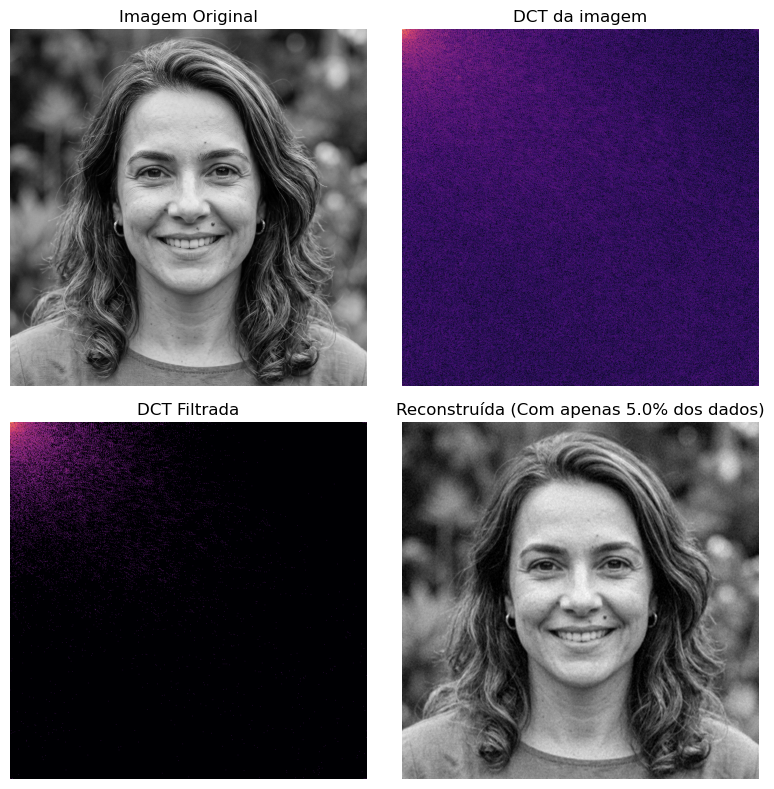

In [24]:
img = np.array(Image.open("../../dados/foto_artificial.png").convert("L"))

# Transforma para a Frequência
Fimg = dct(img)

# Define a agressividade da compressão
# Vamos jogar fora 95% dos dados!
percentile = 95.0 
Fimg_fil = filter_dct(Fimg, percentile)

# Reconstrução
img_rec = reconstruct_image(Fimg_fil)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Imagem Original')

axes[0, 1].imshow(np.log(1 + np.abs(Fimg)), cmap='magma')
axes[0, 1].set_title('DCT da imagem')

axes[1, 0].imshow(np.log(1 + np.abs(Fimg_fil)), cmap='magma')
axes[1, 0].set_title('DCT Filtrada')

axes[1, 1].imshow(img_rec, cmap='gray')
axes[1, 1].set_title(f'Reconstruída (Com apenas {100 - percentil}% dos dados)')


for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()

Com apenas 5% dos coeficientes de frequência, a imagem pode ser reconstruída com boa qualidade. Podemos então salvar os coeficientes DCT em um formato compacto para reduzir a quantidade de dados.

In [ ]:
def coo_format(Fimg_fil):
    """
    Formato Coordinate List (COO) é uma forma eficiente de armazenar matrizes esparsas. Armazenamos
    Apenas as posições (linhas e colunas) e os valores dos coeficientes que não são zero na matriz.
    """
    # Converte valores para float32 (Metade do peso do float64)
    dct_32 = Fimg_fil.astype(np.float32)
    
    # Encontra as posições (linhas e colunas) onde o valor NÃO é zero
    rows, cols = np.nonzero(dct_32)
    
    # Extrai os valores exatos nessas posições
    values = dct_32[rows, cols]
    
    # Imagens raramente passam de 65.535 pixels de lado. 
    # Usar uint16 gasta apenas 2 bytes por coordenada em vez de 8 bytes (int64)
    rows = rows.astype(np.uint16)
    cols = cols.astype(np.uint16)
    
    # Salva as dimensões originais da imagem para a reconstrução
    h, w = dct_32.shape
    shape_info = np.array([h, w], dtype=np.uint16)
    
    return shape_info, rows, cols, values

shape, rows, cols, values = coo_format(Fimg_fil)

In [25]:
# Custo para armazenar a imagem original:
# Cada pixel é uint8 (1 byte), e a imagem tem tamanho h x w
h, w = img.shape
img_size = h * w / 2**10  # Convertendo para KB
print(f"Custo para armazenar a imagem original: {img_size} KB")

# Custo para armazenar a imagem comprimida usando COO:
# Cada valor é float32 (4 bytes), cada linha e coluna é uint16 (2 bytes)
# Total = 4 bytes (valor) + 2 bytes (linha) + 2 bytes (coluna) = 8 bytes por coeficiente não-zero
coo_cost = len(rows) * (4 + 2 + 2) + 4  # +4 bytes para armazenar as dimensões (altura, largura)
coo_cost = coo_cost / 2**10  # Convertendo para KB
print(f"Custo total para armazenar a imagem comprimida usando COO: {coo_cost} KB")

Custo para armazenar a imagem original: 576.0 KB
Custo total para armazenar a imagem comprimida usando COO: 230.41015625 KB


Podemos utilizar algoritmos de compressão para comprimir ainda mais os dados:

In [ ]:
import os

# savez_compressed tenta comprimir os dados usando gzip
np.savez_compressed(
        "img.npz", 
        img=img
    )
np.savez_compressed(
        "dct.npz", 
        shape=shape, 
        linhas=rows, 
        colunas=cols, 
        valores=values
    )

# Imprime os tamanhos dos arquivos salvos para comparação
print(f"img.npz: {os.path.getsize("img.npz") / 1024:.2f} KB")
print(f"dct.npz: {os.path.getsize("dct.npz") / 1024:.2f} KB")
 

_img.npz: 523.29 KB
_dct.npz: 129.67 KB
